In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("measures_v2.csv")
df

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,1.871008e-01,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,2.454175e-01,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,1.766153e-01,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,2.383027e-01,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,2.081967e-01,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1330811,-2.152128,30.721298,45.274497,0.791801,41.934347,0.000380,-2.000169,1.097528,62.147780,38.653720,23.989078,-8.116730e-60,71
1330812,-2.258684,30.721306,45.239017,0.778900,41.868923,0.002985,-2.000499,1.097569,62.142646,38.656328,23.970700,-5.815891e-60,71
1330813,-2.130312,30.721312,45.211576,0.804914,41.804819,0.002301,-1.999268,1.098765,62.138387,38.650923,23.977234,-4.167268e-60,71
1330814,-2.268498,30.721316,45.193508,0.763091,41.762220,0.005662,-2.000999,1.095696,62.133422,38.655686,24.001421,-2.985978e-60,71


In [20]:
X = df.drop("pm",axis=1)
y = df["pm"]

In [21]:
X


,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,18.316547,19.850691,1.871008e-01,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,18.314955,19.850672,2.454175e-01,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,18.326307,19.850657,1.766153e-01,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,18.330833,19.850647,2.383027e-01,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,18.326662,19.850639,2.081967e-01,17
...,...,...,...,...,...,...,...,...,...,...,...,...
1330811,-2.152128,30.721298,45.274497,0.791801,41.934347,0.000380,-2.000169,1.097528,38.653720,23.989078,-8.116730e-60,71
1330812,-2.258684,30.721306,45.239017,0.778900,41.868923,0.002985,-2.000499,1.097569,38.656328,23.970700,-5.815891e-60,71
1330813,-2.130312,30.721312,45.211576,0.804914,41.804819,0.002301,-1.999268,1.098765,38.650923,23.977234,-4.167268e-60,71
1330814,-2.268498,30.721316,45.193508,0.763091,41.762220,0.005662,-2.000999,1.095696,38.655686,24.001421,-2.985978e-60,71


In [22]:
y

0          24.554214
1          24.538078
2          24.544693
3          24.554018
4          24.565397
             ...    
1330811    62.147780
1330812    62.142646
1330813    62.138387
1330814    62.133422
1330815    62.131429
Name: pm, Length: 1330816, dtype: float64

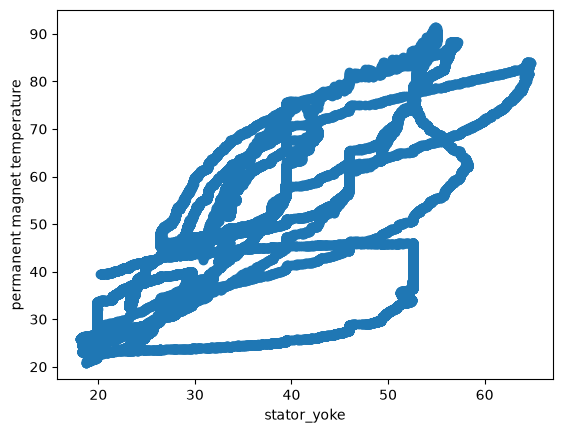

In [23]:
fig, ax = plt.subplots()
ax.scatter(df["stator_yoke"][:100000],
      df["pm"][:100000])
ax.set_xlabel("stator_yoke")
ax.set_ylabel("permanent magnet temperature");

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [25]:
%%time
np.random.seed(42)
# from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
model = XGBRegressor(n_jobs=-1)
model.fit(X_train,y_train)
model.score(X_test,y_test)

CPU times: total: 41.7 s
Wall time: 3.96 s


0.9877285611494999

In [28]:
y_preds = model.predict(X_test)

In [29]:
y_preds

array([89.196434, 78.101585, 60.56126 , ..., 60.994583, 47.28421 ,
       43.728   ], shape=(266164,), dtype=float32)

In [30]:
np.random.seed(42)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_preds)
mse

4.433017869850307

In [31]:
np.random.seed(42)
from sklearn.metrics import r2_score
rope = r2_score(y_test,y_preds)

In [32]:
rope

0.9877285611494999

In [33]:
model.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': True,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [34]:
!pip install xgboost

In [35]:
np.random.seed(42)

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor 

from sklearn.model_selection import GroupKFold, cross_val_score
groups = df["profile_id"]
X = df.drop(columns=["pm","profile_id"])
y = df["pm"]

gkf = GroupKFold(n_splits=5)
model = XGBRegressor(n_jobs=-1)
scores = cross_val_score(model,X,y,cv=gkf,groups=groups,scoring='r2')

param_distributions = {"n_estimators":[10,100,200],
                      "max_depth":[3,5,10],
                      "learning_rate":[0.005,0.1,0.2],
                      "colsample_bytree":[0.7,0.2,1.0],
                      "min_child_weight":[1,2,8]}
model = XGBRegressor(n_jobs=-1)
n_iter = 18
tune = RandomizedSearchCV(estimator=model,
                         param_distributions=param_distributions,
                         n_iter=n_iter,
                         verbose=2,
                         random_state=42,
                         cv=gkf)
tune.fit(X,y,groups=groups)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END colsample_bytree=0.7, learning_rate=0.005, max_depth=10, min_child_weight=8, n_estimators=10; total time=   0.8s
[CV] END colsample_bytree=0.7, learning_rate=0.005, max_depth=10, min_child_weight=8, n_estimators=10; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.005, max_depth=10, min_child_weight=8, n_estimators=10; total time=   0.8s
[CV] END colsample_bytree=0.7, learning_rate=0.005, max_depth=10, min_child_weight=8, n_estimators=10; total time=   0.8s
[CV] END colsample_bytree=0.7, learning_rate=0.005, max_depth=10, min_child_weight=8, n_estimators=10; total time=   0.8s
[CV] END colsample_bytree=0.7, learning_rate=0.005, max_depth=3, min_child_weight=8, n_estimators=10; total time=   0.5s
[CV] END colsample_bytree=0.7, learning_rate=0.005, max_depth=3, min_child_weight=8, n_estimators=10; total time=   0.4s
[CV] END colsample_bytree=0.7, learning_rate=0.005, max_depth=3, min_child_weight=8, n_

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.2, ...], 'learning_rate': [0.005, 0.1, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",18
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit``

In [36]:
scores.mean()

np.float64(0.8129647597432783)

In [37]:
tune.best_params_

{'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 5,
 'learning_rate': 0.2,
 'colsample_bytree': 1.0}

In [38]:
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.9877285611494999

In [39]:
y_preds = model.predict(X_test)



In [40]:
np.random.seed(42)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error,max_error
predcitions = cross_val_predict(tune.best_estimator_,X,y,cv=gkf,groups=groups,n_jobs=-1)
mae = mean_absolute_error(y,predcitions)
me  = max_error(y,predcitions)
print(f"Mean_absolute_error is {mae} and Max Error is {me}")

Mean_absolute_error is 5.854093675328251 and Max Error is 71.81702423095703


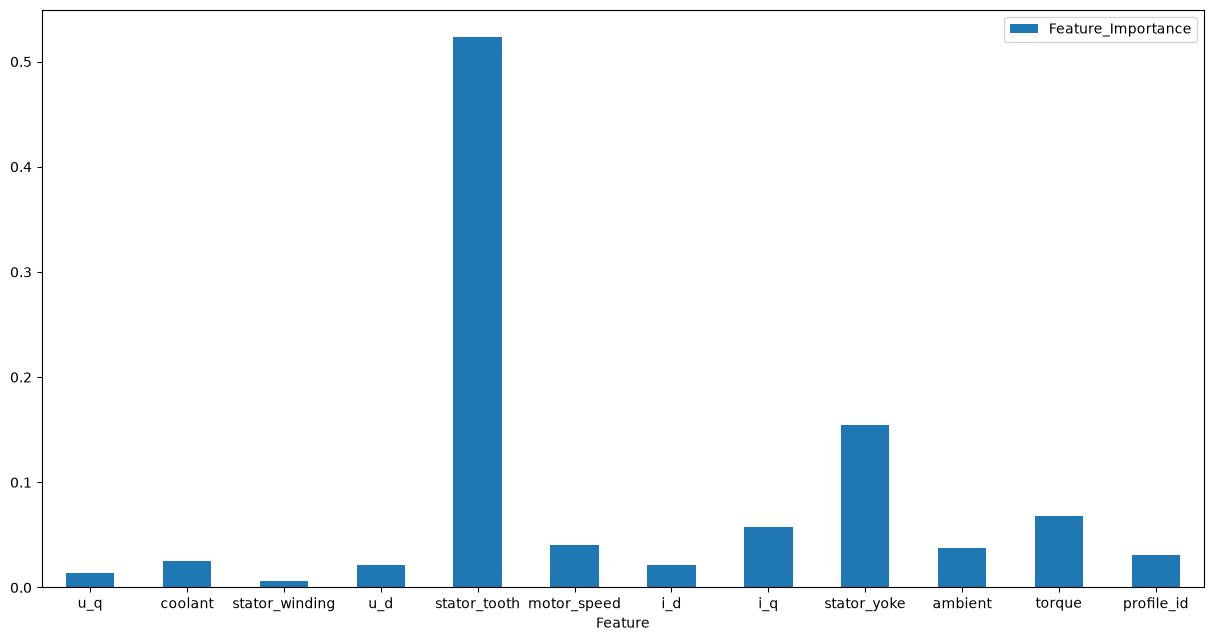

In [72]:
ft = model.feature_importances_
ft_df = pd.DataFrame({"Feature":X_train.columns,
                     "Feature_Importance":ft})
ft_df.plot(kind="bar",x="Feature",y="Feature_Importance",figsize=(15,7.5))
plt.xticks(rotation=0);
plt.savefig("important_features_affecting_the_temperature_of_permanent_magnet_synchronus_motors.png")

In [43]:
import pandas as pd

# 1. Build an error tracking table
analysis_df = pd.DataFrame({
    'profile_id': groups, # Pulling from your original groups variable
    'actual_temp': y,
    'predicted_temp': predcitions,
    'error': abs(y - predcitions)
})

# 2. Filter for extreme danger anomalies (>30°C miss)
danger_zone = analysis_df[analysis_df['error'] > 30]

# 3. Print the damage report
print(f"Total rows analyzed: {len(analysis_df):,}")
print(f"Rows with >30°C error: {len(danger_zone):,}")
print(f"Percentage of data corrupted: {(len(danger_zone) / len(analysis_df) * 100):.3f}%\n")

print("Drive Cycles (Profiles) causing the catastrophic failures:")
print(danger_zone['profile_id'].value_counts().head(10))

Total rows analyzed: 1,330,816
Rows with >30°C error: 4,317
Percentage of data corrupted: 0.324%

Drive Cycles (Profiles) causing the catastrophic failures:
profile_id
29    2667
36     714
27     509
75     139
79      87
66      86
4       34
71      33
20      14
41      13
Name: count, dtype: int64


In [44]:
# 1. Filter out the known corrupted profiles
bad_profiles = [29, 36, 27]
df_clean = df[~df['profile_id'].isin(bad_profiles)].copy()

print(f"Original rows: {len(df):,}")
print(f"Cleaned rows: {len(df_clean):,}")

# 2. Rebuild the variables
groups = df_clean["profile_id"]
X = df_clean.drop(columns=["pm", "profile_id"])
y = df_clean["pm"]

Original rows: 1,330,816
Cleaned rows: 1,251,488


In [45]:
tune.best_estimator_


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [46]:
# Pass your existing best_model into the new clean X and y
clean_predictions = cross_val_predict(tune.best_estimator_, X, y, cv=gkf, groups=groups, n_jobs=-1)

clean_mae = mean_absolute_error(y, clean_predictions)
clean_max_error = max_error(y, clean_predictions)

print(f"\n--- Final Clean Metrics ---")
print(f"Honest MAE: ±{clean_mae:.2f}°C")
print(f"Honest Max Error: {clean_max_error:.2f}°C")
print(f"Safe Kill-Switch Limit: {(120 - clean_max_error):.1f}°C")


--- Final Clean Metrics ---
Honest MAE: ±5.55°C
Honest Max Error: 40.59°C
Safe Kill-Switch Limit: 79.4°C


In [49]:
fg = pd.DataFrame(y,predcitions,columns=["pm","predicted pm"])

In [50]:
fg

,pm,predicted pm
16.749802,NaN,NaN
18.401403,NaN,NaN
17.411774,NaN,NaN
18.401403,NaN,NaN
22.377441,NaN,NaN
...,...,...
55.907501,NaN,NaN
54.290462,NaN,NaN
55.576767,NaN,NaN
55.576767,NaN,NaN


In [51]:
df

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,1.871008e-01,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,2.454175e-01,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,1.766153e-01,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,2.383027e-01,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,2.081967e-01,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1330811,-2.152128,30.721298,45.274497,0.791801,41.934347,0.000380,-2.000169,1.097528,62.147780,38.653720,23.989078,-8.116730e-60,71
1330812,-2.258684,30.721306,45.239017,0.778900,41.868923,0.002985,-2.000499,1.097569,62.142646,38.656328,23.970700,-5.815891e-60,71
1330813,-2.130312,30.721312,45.211576,0.804914,41.804819,0.002301,-1.999268,1.098765,62.138387,38.650923,23.977234,-4.167268e-60,71
1330814,-2.268498,30.721316,45.193508,0.763091,41.762220,0.005662,-2.000999,1.095696,62.133422,38.655686,24.001421,-2.985978e-60,71
